C:\Users\COMPUTER\AppData\Local\Temp\ipykernel_19728\162474738.py:17: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_train = pd.read_csv(os.path.join(base_path, "train/X_train.txt"), delim_whitespace=True, header=None)
C:\Users\COMPUTER\AppData\Local\Temp\ipykernel_19728\162474738.py:19: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  X_test = pd.read_csv(os.path.join(base_path, "test/X_test.txt"), delim_whitespace=True, header=None)



--- Decision Tree ---
Accuracy: 0.8622
Precision: 0.8633
Recall: 0.8622
F1 Score: 0.8617


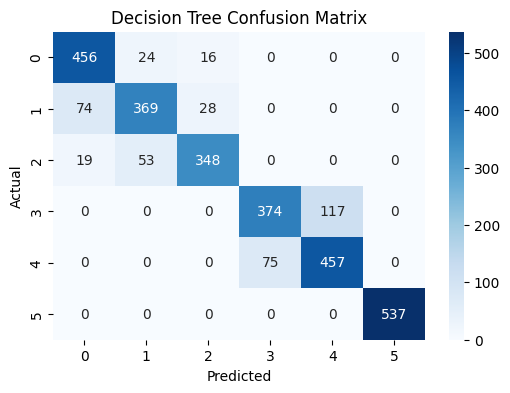


--- Random Forest ---
Accuracy: 0.9260
Precision: 0.9274
Recall: 0.9260
F1 Score: 0.9260


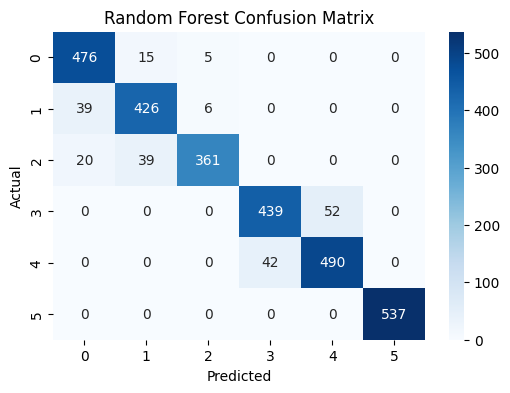


--- SVM ---
Accuracy: 0.9522
Precision: 0.9526
Recall: 0.9522
F1 Score: 0.9521


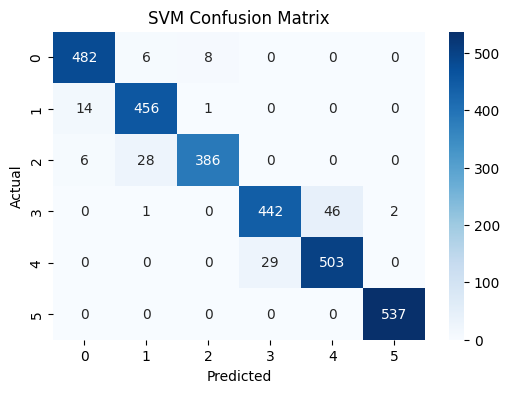

In [1]:
# Task 3: Hands-on ML - Train and evaluate multiple models

# Step 1: Import Libraries
import os
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Step 2: Load HAR dataset
base_path = "UCI_HAR_Dataset/UCI HAR Dataset"  # Change this to your path
X_train = pd.read_csv(os.path.join(base_path, "train/X_train.txt"), delim_whitespace=True, header=None)
y_train = pd.read_csv(os.path.join(base_path, "train/y_train.txt"), header=None)
X_test = pd.read_csv(os.path.join(base_path, "test/X_test.txt"), delim_whitespace=True, header=None)
y_test = pd.read_csv(os.path.join(base_path, "test/y_test.txt"), header=None)

# Step 3: Encode Labels
le = LabelEncoder()
y_train = le.fit_transform(y_train.values.ravel())
y_test = le.transform(y_test.values.ravel())

# Step 4: Scale Features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Step 5: Define multiple models
models = {
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'SVM': SVC(kernel='rbf', probability=True, random_state=42)
}

# Step 6: Train, Predict, Evaluate
for name, model in models.items():
    print(f"\n--- {name} ---")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Evaluation Metrics
    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')
    
    print(f"Accuracy: {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall: {rec:.4f}")
    print(f"F1 Score: {f1:.4f}")
    
    # Confusion Matrix Heatmap
    plt.figure(figsize=(6,4))
    sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()
